In [ ]:
#import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, roc_curve, roc_auc_score, precision_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/adult.csv')

print("Adult dataset loaded successfully.")

Adult dataset loaded successfully.


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.shape

(32561, 15)

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 24


In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
categorical_cols = [
    'workclass',
    'occupation',
    'native.country'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.drop(['fnlwgt'], axis=1, inplace=True)

In [ ]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = df.select_dtypes(
    include=['object']
).columns

print("Numerical Features:")
for col in numerical_features:
    print("-", col)

print("\nCategorical Features:")
for col in categorical_features:
    print("-", col)

Numerical Features:
- age
- education.num
- capital.gain
- capital.loss
- hours.per.week

Categorical Features:
- workclass
- education
- marital.status
- occupation
- relationship
- race
- sex
- native.country
- income


In [ ]:
df.columns

Index(['age', 'workclass', 'education', 'education.num', 'marital.status',
       'occupation', 'relationship', 'race', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'native.country', 'income'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_features = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]
for col in categorical_features:
    df[col] = le.fit_transform(df[col])
print("Categorical features encoded successfully")

Categorical features encoded successfully


In [ ]:
df['income'] = df['income'].str.strip()
df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})
print("Target column encoded successfully")
print(df['income'].value_counts())

Target column encoded successfully
income
0    24720
1     7841
Name: count, dtype: int64


In [ ]:
# Separate features and target
x = df.drop('income', axis=1)
y = df['income']
print("Features (X) and target (y) separated successfully")
print("X shape:", x.shape)
print("y shape:", y.shape)

Features (X) and target (y) separated successfully
X shape: (32561, 13)
y shape: (32561,)


In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (26048, 13)
Testing set size: (6513, 13)


In [ ]:
# Model building
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
model.fit(x_train, y_train)
#print("Decision Tree model trained successfully")

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# Predictions on test data
y_pred = model.predict(x_test)
print("Predictions generated successfully")

Predictions generated successfully


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4370  575]
 [ 630  938]]


In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      4945
           1       0.62      0.60      0.61      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.74      0.74      6513
weighted avg       0.81      0.81      0.81      6513



In [ ]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 97.81%
Testing Accuracy: 81.50%


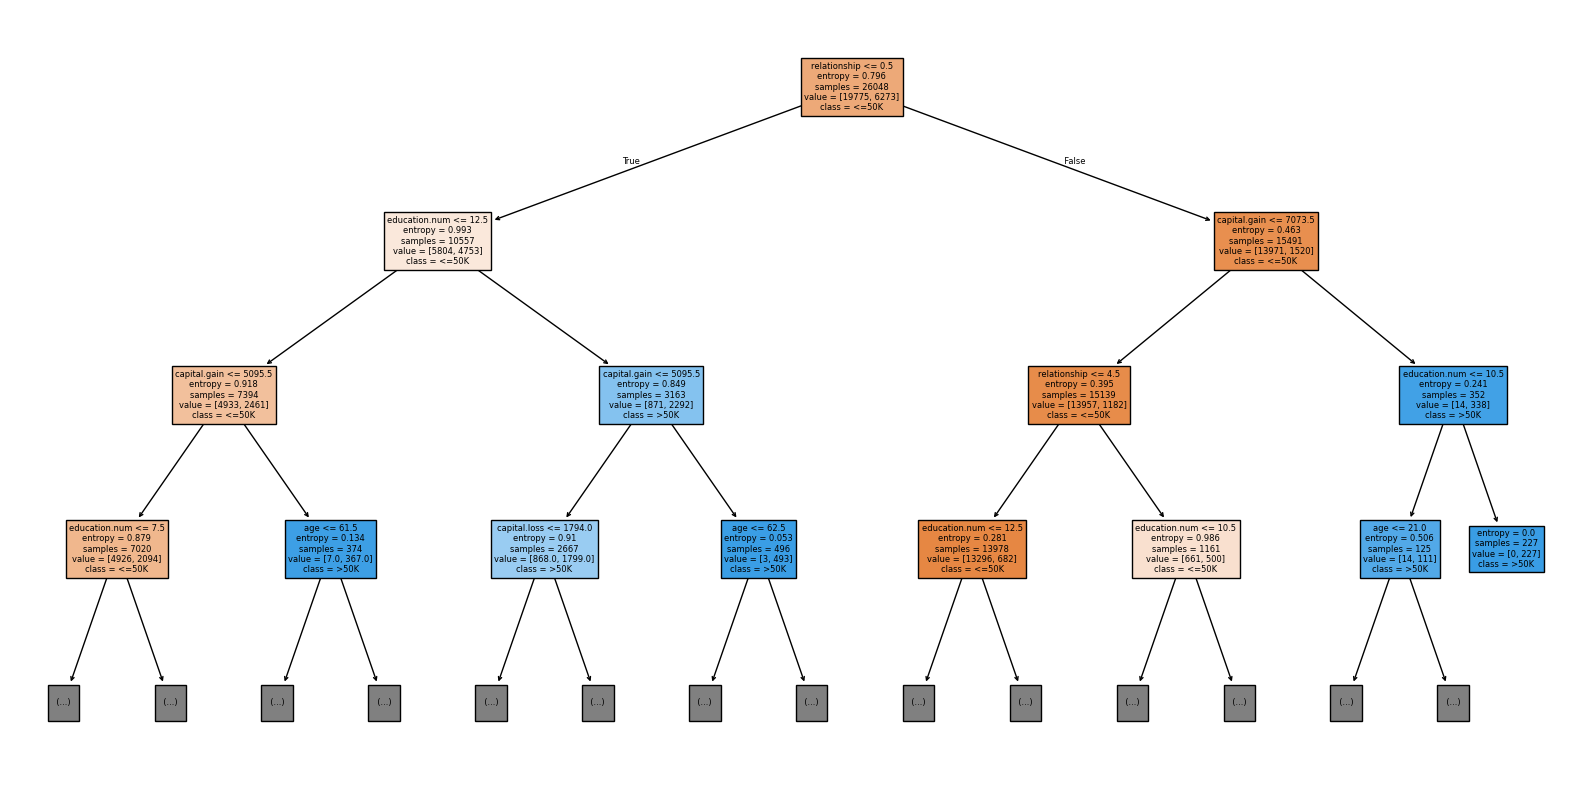

In [ ]:
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(
    model,
    max_depth=3,
    feature_names=x.columns,
    class_names=['<=50K', '>50K'],
    filled=True
)
plt.show()

In [ ]:
# AUC Score
auc_score = roc_auc_score(y_test, y_pred)
print("AUC Score:", auc_score)

AUC Score: 0.7409676079734219


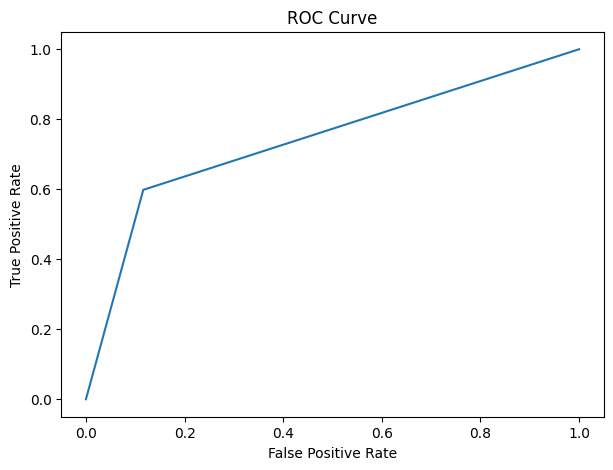

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()